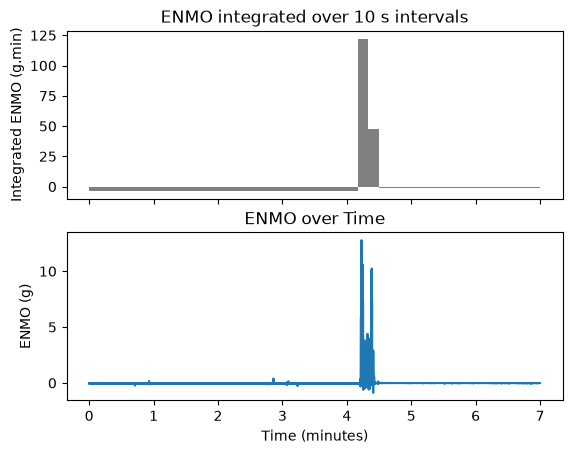

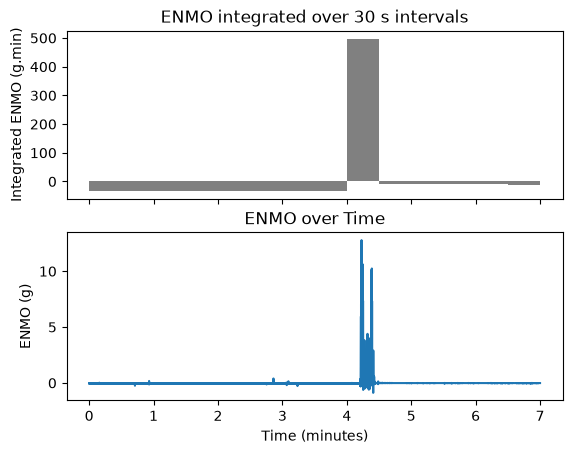

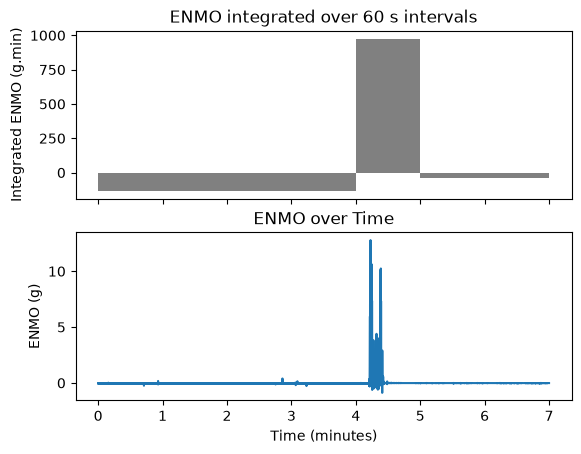

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def lire_donnees(nom_fichier):
    # skiprows=1 : on saute la première ligne (c'est un commentaire)
    return pd.read_csv(nom_fichier, skiprows=1)


def calculer_enmo(donnees):
    # norme = longueur du vecteur (x, y, z), puis on enlève 1 g (la gravité)
    norme = np.sqrt(donnees["x"]**2 + donnees["y"]**2 + donnees["z"]**2)
    return norme - 1


def enmo_integre(temps, enmo, duree):
    # On découpe le temps en morceaux (époques) de "duree" secondes
    debuts = []
    valeurs = []
    debut = 0
    while debut < temps.max():
        fin = debut + duree
        dans_epoque = (temps >= debut) & (temps < fin)   # mesures de ce morceau
        somme = enmo[dans_epoque].sum()                  # on additionne l'ENMO
        valeurs.append(somme * duree / 60)               # résultat en g.min
        debuts.append(debut / 60)                        # début en minutes
        debut = fin
    return debuts, valeurs


def faire_graphique(temps, enmo, duree):
    debuts, valeurs = enmo_integre(temps, enmo, duree)

    fig, (haut, bas) = plt.subplots(2, 1, sharex=True)

    # Graphique du haut : les barres
    haut.bar(debuts, valeurs, width=duree / 60, align="edge", color="gray")
    haut.set_title(f"ENMO integrated over {duree} s intervals")
    haut.set_ylabel("Integrated ENMO (g.min)")

    # Graphique du bas : la courbe
    bas.plot(temps / 60, enmo)
    bas.set_title("ENMO over Time")
    bas.set_xlabel("Time (minutes)")
    bas.set_ylabel("ENMO (g)")

    plt.show()


# ----- Programme principal -----
donnees = lire_donnees("Mesures/0_z.csv")
temps = donnees["t"]
enmo = calculer_enmo(donnees)

for duree in [10, 30, 60]:
    faire_graphique(temps, enmo, duree)




# ENMO intégré par époque

**Dépôt GitHub :** [lien vers ton dépôt](https://github.com/TON-NOM/TON-DEPOT)

**Membres de l'équipe :** Prénom Nom, Prénom Nom

**Objectif :** à partir des mesures d'un accéléromètre porté au poignet, tracer l'ENMO intégré sur des époques de 10 s, 30 s et 60 s.

---

## Bibliothèques utilisées

- `pandas` : lire le fichier CSV.
- `numpy` : faire les calculs (racine carrée).
- `matplotlib` : dessiner les graphiques.

---

## Fonction 1 : `lire_donnees`

Le fichier `0_z.csv` contient 4 colonnes : le temps `t` (en secondes) et l'accélération sur trois axes `x`, `y`, `z` (en g).

La première ligne du fichier est un commentaire, pas une mesure. On la saute avec `skiprows=1`, sinon pandas la prendrait pour les noms de colonnes.

---

## Fonction 2 : `calculer_enmo`

ENMO signifie *Euclidean Norm Minus One* (norme euclidienne moins un).

1. On calcule la norme du vecteur d'accélération : √(x² + y² + z²). Elle représente l'accélération totale, quelle que soit la direction.
2. On retire 1, car la gravité terrestre vaut 1 g. Quand le poignet est immobile, la norme vaut environ 1 et l'ENMO est proche de 0.

On ne remplace pas les valeurs négatives par 0, car les graphiques attendus montrent de petites valeurs négatives au repos.

---

## Fonction 3 : `enmo_integre`

Une **époque** est un morceau de temps de durée fixe (10 s, 30 s ou 60 s).

Pour chaque époque :
1. On garde les mesures dont le temps est dans cette époque.
2. On additionne leur ENMO.
3. On multiplie par `durée / 60` pour obtenir un résultat en g.min.

La fonction renvoie deux listes : le début de chaque époque (en minutes) et la valeur de l'ENMO intégré correspondante.

Plus l'activité est intense, plus la valeur est grande. Au repos, elle est proche de 0.

---

## Fonction 4 : `faire_graphique`

La figure contient deux graphiques l'un au-dessus de l'autre, avec le même axe du temps :

- **En haut :** des barres grises qui montrent l'ENMO intégré pour chaque époque. Chaque barre commence au début de l'époque et a pour largeur la durée de l'époque.
- **En bas :** la courbe de l'ENMO mesuré à chaque instant, pour voir le signal brut.

Comparer les deux permet de voir comment les barres résument la courbe.

---

## Programme principal

On lit le fichier, on calcule l'ENMO, puis on trace le graphique pour chaque durée d'époque : 10 s, 30 s et 60 s.

---

## Observation

Vers 4 minutes, l'ENMO devient très élevé : c'est un moment de mouvement intense. Le reste du temps, la valeur reste proche de 0 (poignet quasi immobile).

Avec une époque courte (10 s), on voit mieux la durée exacte du mouvement. Avec une époque longue (60 s), le graphique est plus simple mais moins précis dans le temps.